# 5. GRAND and TAMBO

The claim this project rests on is that GRAND and TAMBO ask the **same structural
question** and differ only in their numbers. This notebook shows what those numbers are
and why each one is what it is.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import arrival_scan
import figures
import site_searcher as ss

grid = ss.resolve_grid_geometry("no-such-file.tif", -15.6, cell_size_deg=1/3600)

## What differs

| | GRAND | TAMBO | why |
|---|---|---|---|
| slope band | 3–25° | 20–60° | deployable ground vs a canyon wall |
| far-wall slope | unset | ≥ 25° | TAMBO's tau exits a *wall* |
| distance | 10–40 km | 2–5 km | to the horizon, or across a canyon |
| arrival window | ±3° | ±20° | Earth-skimming, vs a wall subtending tens of degrees |
| spacing | 1 km | 100 m | radio antennas vs particle detectors |
| `min_width_km` | 2.0 | 0.0 | a compact array vs a strip along a wall |
| Fresnel | 50 MHz | none | radio propagation, or none |
| geomagnetic | on | off | emission goes as $|v\times B|$; particles do not care |
| grammage | threshold | band | radio propagates; particle content dies |

Every one of those is a configuration key. None is a code path.

## The canyon geometry

Drawn to scale — unlike a GRAND search, a canyon needs no vertical exaggeration, and
the arrival directions really do span tens of degrees.

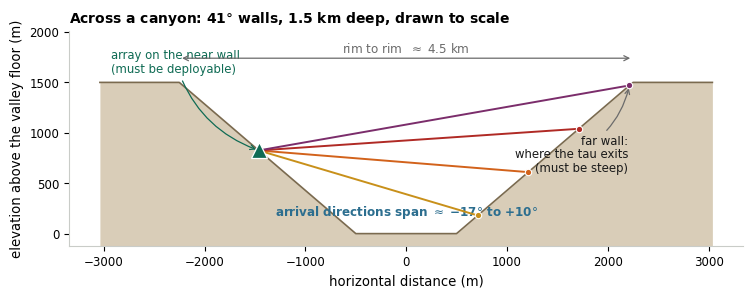

In [2]:
figures.canyon_geometry()
plt.show()

## Building a canyon, and scanning across it

The wall slope is a parameter, so the geometry the scan recovers can be checked against
the number the terrain was built with.

In [3]:
def canyon(n, cell_x, floor_width_m=1000.0, depth_m=1500.0, wall_slope_deg=40.6):
    """Two opposing walls of known slope, with a flat floor between them."""
    cols = np.arange(n, dtype=np.float64)[None, :].repeat(n, 0)
    x = cols * cell_x
    centre = (n * cell_x) / 2.0
    from_edge = np.abs(x - centre) - floor_width_m / 2.0
    rise = np.clip(from_edge, 0.0, None) * np.tan(np.radians(wall_slope_deg))
    return (3500.0 - depth_m + np.clip(rise, 0.0, depth_m)).astype(np.float32)


n = 400
for wall in (25.0, 40.6):
    z = canyon(n, grid.cell_size_x, wall_slope_deg=wall)
    col = int((n * grid.cell_size_x / 2.0 - 1200.0) / grid.cell_size_x)
    cand = np.array([[n // 2, float(col), 90.0]])       # part-way down the west wall
    r = arrival_scan.scan(cand, z, grid, n_azimuths=1, half_width_deg=0.0,
                          use_aspect=True, elev_min_deg=-25.0, elev_max_deg=25.0,
                          n_elev_bins=25, min_dist_km=0.3, max_dist_km=8.0,
                          max_range_m=8000.0, min_target_slope_deg=wall - 5.0)
    print(f"built a {wall:>4.1f} deg wall  ->  measured "
          f"{r['target_slope_deg'][0]:>4.1f} deg   "
          f"({int(r['cells'][0])} directions accepted)")

built a 25.0 deg wall  ->  measured 25.0 deg   (12 directions accepted)
built a 40.6 deg wall  ->  measured 40.6 deg   (17 directions accepted)


## Why the far wall needs its own criterion

Without it, the scan asks only whether *rock* lies at the right range and bearing — and
on real mountainous terrain something nearly always does. Before this criterion existed,
**92% of Andean candidates passed** a canyon-shaped test.

Watch what the floor does: a shallow wall stops qualifying.

In [4]:
z = canyon(n, grid.cell_size_x, wall_slope_deg=15.0)      # a gentle valley
col = int((n * grid.cell_size_x / 2.0 - 1200.0) / grid.cell_size_x)
cand = np.array([[n // 2, float(col), 90.0]])

for floor in (None, 10.0, 30.0):
    kw = {} if floor is None else {"min_target_slope_deg": floor}
    r = arrival_scan.scan(cand, z, grid, n_azimuths=1, half_width_deg=0.0,
                          use_aspect=True, elev_min_deg=-25.0, elev_max_deg=25.0,
                          n_elev_bins=25, min_dist_km=0.3, max_dist_km=8.0,
                          max_range_m=8000.0, **kw)
    label = "no far-wall criterion" if floor is None else f"require >= {floor:.0f} deg"
    print(f"{label:>24}:  {int(r['cells'][0]):>3} directions accepted")

print("\nA 15 deg valley satisfies a 10 deg floor and fails a 30 deg one,")
print("which is exactly the discrimination a canyon search needs.")

   no far-wall criterion:   13 directions accepted
       require >= 10 deg:    8 directions accepted
       require >= 30 deg:    0 directions accepted

A 15 deg valley satisfies a 10 deg floor and fails a 30 deg one,
which is exactly the discrimination a canyon search needs.


## An honest caveat

Note that the *unfiltered* mean target slope is **not** the wall slope: rays aimed lower
strike the flat canyon floor, whose slope really is zero, so the mean over all accepted
directions is a mixture. Filtering is what isolates the wall.

This broke a first draft of the tests, and it is worth stating plainly rather than
discovering.

In [5]:
z = canyon(n, grid.cell_size_x, wall_slope_deg=40.6)
cand = np.array([[n // 2, float(col), 90.0]])
base = arrival_scan.scan(cand, z, grid, n_azimuths=1, half_width_deg=0.0,
                         use_aspect=True, elev_min_deg=-25.0, elev_max_deg=25.0,
                         n_elev_bins=25, min_dist_km=0.3, max_dist_km=8.0,
                         max_range_m=8000.0)
cut = arrival_scan.scan(cand, z, grid, n_azimuths=1, half_width_deg=0.0,
                        use_aspect=True, elev_min_deg=-25.0, elev_max_deg=25.0,
                        n_elev_bins=25, min_dist_km=0.3, max_dist_km=8.0,
                        max_range_m=8000.0, min_target_slope_deg=35.0)
print("wall built at 40.6 deg")
print(f"  unfiltered mean target slope: {base['target_slope_deg'][0]:5.1f} deg  <- a mixture")
print(f"  filtered to wall hits:        {cut['target_slope_deg'][0]:5.1f} deg  <- the wall")

wall built at 40.6 deg
  unfiltered mean target slope:  34.5 deg  <- a mixture
  filtered to wall hits:         40.6 deg  <- the wall


## Where to go next

- **[6. Combining experiments](06_combining_and_sensitivity.ipynb)** — where both are
  viable at once, and how firm any of it is.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Criteria and scoring](04_criteria_and_scoring.ipynb). Next: [Combining and sensitivity](06_combining_and_sensitivity.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*